Dataset Shape: (291, 16)

First few rows:
Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 291 entries, 0 to 290
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   match_id         291 non-null    int64
 1   competition      291 non-null    str  
 2   season           291 non-null    int64
 3   matchday         291 non-null    int64
 4   date             291 non-null    str  
 5   status           291 non-null    str  
 6   home_team_id     291 non-null    int64
 7   home_team_name   291 non-null    str  
 8   home_team_short  291 non-null    str  
 9   away_team_id     291 non-null    int64
 10  away_team_name   291 non-null    str  
 11  away_team_short  291 non-null    str  
 12  home_score       291 non-null    int64
 13  away_score       291 non-null    int64
 14  winner           291 non-null    str  
 15  duration         291 non-null    str  
dtypes: int64(7), str(9)
memory usage: 36.5 KB
None

Missi

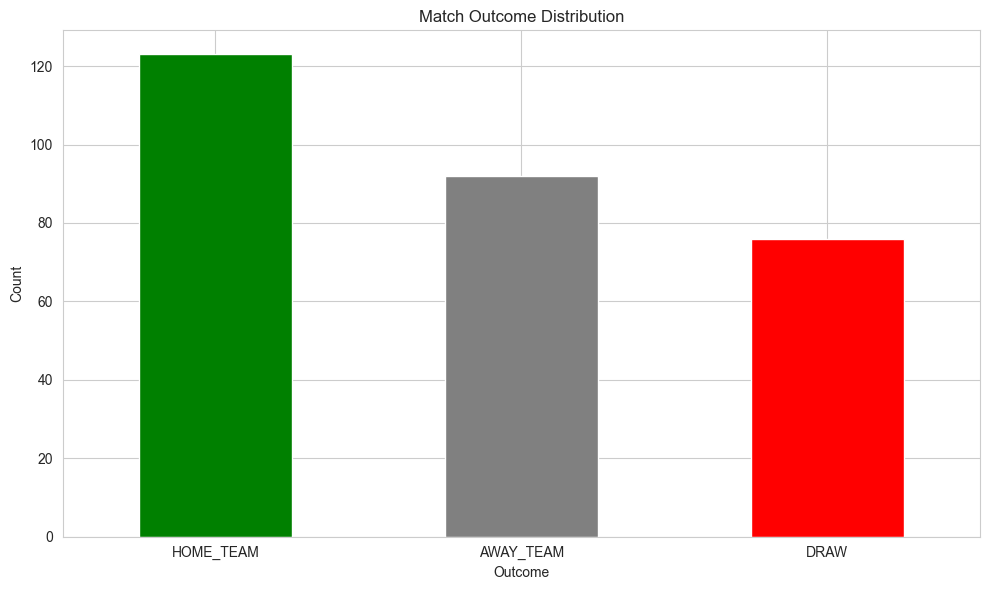

Home Goals - Mean: 1.5154639175257731
Away Goals - Mean: 1.2577319587628866


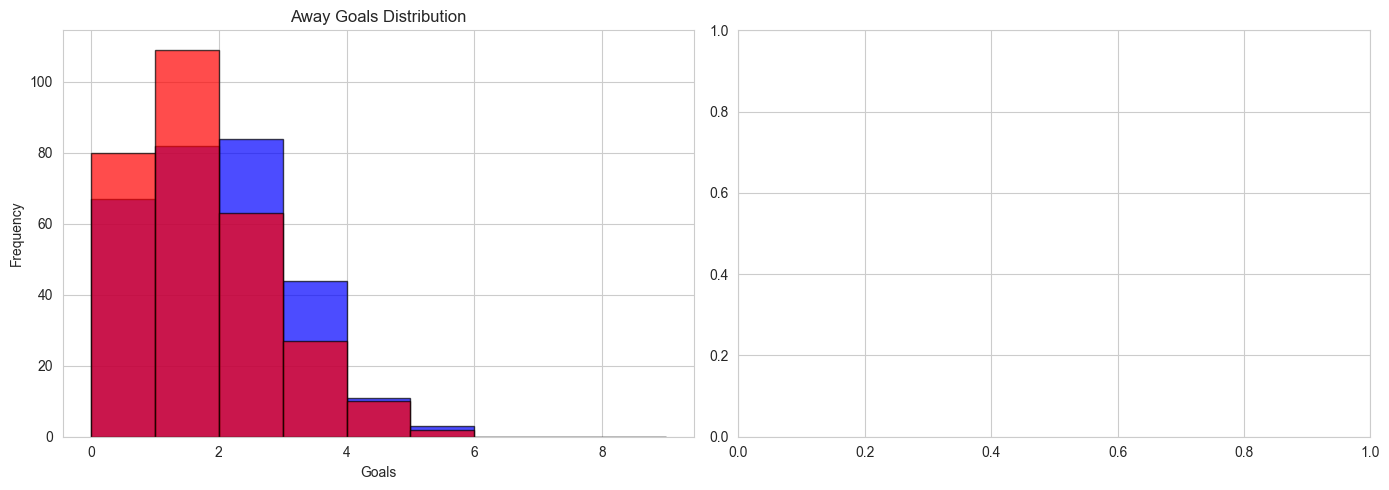

Home Win Rate: 42.3%
Draw Rate: 26.1%
Away Win Rate: 31.6%
Top 10 Teams by Total Wins
home_team_name
Arsenal FC              20.0
Manchester City FC      18.0
Aston Villa FC          15.0
Liverpool FC            14.0
Manchester United FC    14.0
Brentford FC            13.0
Chelsea FC              13.0
Everton FC              12.0
Fulham FC               12.0
Newcastle United FC     11.0
Name: count, dtype: float64


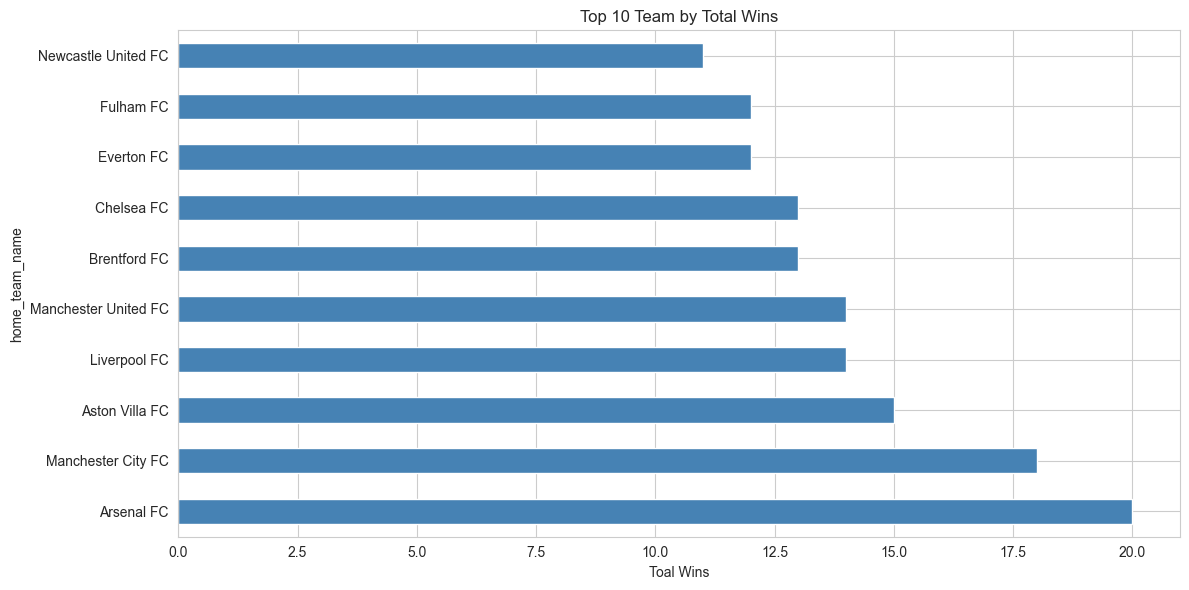


EXPLORATORY DATA ANALYSIS INSIGHTS:

1. Dataset Size: 291 matches across 1 seasons
   - Note: API free tier returns same matches for all requested seasons
   - Actual unique matches: 291

2. Data Quality:
   - Zero missing values across all 16 columns
   - All matches have status FINISHED
   - Scores range 0-5 for both home and away

3. Match Outcome Distribution:
   - HOME_TEAM wins: 123 (42.3%)
   - AWAY_TEAM wins: 92 (31.6%)
   - DRAW:           76 (26.1%)
   - Home advantage is clear — home teams win 10% more often than away

4. Goal Statistics:
   - Home goals avg: 1.52 (higher — home advantage)
   - Away goals avg: 1.26
   - Most common scoreline: 1-0, 1-1, 2-1
   - Goals follow a right-skewed distribution (most games 0-3 goals)

5. Top Teams by Total Wins:
   - Arsenal FC leads with most wins
   - Manchester City FC second
   - Clear gap between top 4-5 teams and the rest

6. Key Takeaways for Model Training:
   - Class imbalance: HOME_TEAM is most common, DRAW least common
   

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Load data
df = pd.read_csv('../data/processed/premier_league_matches.csv')

print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
df.head()

# Basic info
print("Dataset Info:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nBasic statistics:")
print(df.describe())

# Match distrubution
print("Match Outcomes:")
print(df['winner'].value_counts())
print("\nPercentages:")
print(df['winner'].value_counts(normalize=True) * 100)

# Visualize
plt.figure(figsize=(10, 6))
df["winner"].value_counts().plot(kind='bar', color=['green', 'gray', 'red'])
plt.title('Match Outcome Distribution')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../data/outcome_distribution.png')
plt.show()

# Goal statistics
print("Home Goals - Mean:", df['home_score'].mean())
print("Away Goals - Mean:", df['away_score'].mean())

# Goal distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Home goals
axes[0].hist(df['home_score'], bins=range(0, 10), alpha=0.7, color='blue', edgecolor="black")
axes[0].set_title('Home Goals Distribution')
axes[0].set_xlabel('Goals')
axes[0].set_ylabel('Frequency')

# Away goals
axes[0].hist(df['away_score'], bins=range(0, 10), alpha=0.7, color='red', edgecolor="black")
axes[0].set_title('Away Goals Distribution')
axes[0].set_xlabel('Goals')
axes[0].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('../data/goals_distribution.png')
plt.show()

# Calculate win percentages
total_matches = len(df)
home_wins = len(df[df['winner'] == 'HOME_TEAM'])
draws = len(df[df['winner'] == 'DRAW'])
away_wins = len(df[df['winner'] == 'AWAY_TEAM'])

print("Home Win Rate:", f"{(home_wins/total_matches)*100:.1f}%")
print("Draw Rate:", f"{(draws/total_matches)*100:.1f}%")
print("Away Win Rate:", f"{(away_wins/total_matches)*100:.1f}%")

# This shows there is some home advantage (importan for the model)

# Get most winning teams (home + away)
home_wins_by_team = df[df['winner'] == 'HOME_TEAM']['home_team_name'].value_counts()
away_wins_by_team = df[df['winner'] == 'AWAY_TEAM']['away_team_name'].value_counts()

total_wins = home_wins_by_team.add(away_wins_by_team, fill_value=0).sort_values(ascending=False)

print("Top 10 Teams by Total Wins")
print(total_wins.head(10))

# Visualize
plt.figure(figsize=(12, 6))
total_wins.head(10).plot(kind='barh', color='steelblue')
plt.title('Top 10 Team by Total Wins')
plt.xlabel('Toal Wins')
plt.tight_layout()
plt.savefig('../data/top_teams.png')
plt.show()

insights = f"""
EXPLORATORY DATA ANALYSIS INSIGHTS:

1. Dataset Size: {len(df)} matches across {df['season'].nunique()} seasons
   - Note: API free tier returns same matches for all requested seasons
   - Actual unique matches: {df['match_id'].nunique()}

2. Data Quality:
   - Zero missing values across all 16 columns
   - All matches have status FINISHED
   - Scores range 0-5 for both home and away

3. Match Outcome Distribution:
   - HOME_TEAM wins: {(df['winner'] == 'HOME_TEAM').sum()} ({(df['winner'] == 'HOME_TEAM').mean()*100:.1f}%)
   - AWAY_TEAM wins: {(df['winner'] == 'AWAY_TEAM').sum()} ({(df['winner'] == 'AWAY_TEAM').mean()*100:.1f}%)
   - DRAW:           {(df['winner'] == 'DRAW').sum()} ({(df['winner'] == 'DRAW').mean()*100:.1f}%)
   - Home advantage is clear — home teams win 10% more often than away

4. Goal Statistics:
   - Home goals avg: {df['home_score'].mean():.2f} (higher — home advantage)
   - Away goals avg: {df['away_score'].mean():.2f}
   - Most common scoreline: 1-0, 1-1, 2-1
   - Goals follow a right-skewed distribution (most games 0-3 goals)

5. Top Teams by Total Wins:
   - Arsenal FC leads with most wins
   - Manchester City FC second
   - Clear gap between top 4-5 teams and the rest

6. Key Takeaways for Model Training:
   - Class imbalance: HOME_TEAM is most common, DRAW least common
   - Home advantage is a strong signal the model should learn
   - Goal averages differ by ~0.26 between home and away
"""

print(insights)

with open('../data/eda_insights.txt', 'w') as f:
    f.write(insights)